In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
df = pd.read_csv("smartcart_customers.csv")

### Data Understanding

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

### Handle missing values

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

- **Missing Values**

  Missing values in `Income` were replaced with the **median**, which represents the middle value of the data.

In [5]:
# df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [6]:
# Age
df["age"] = 2026 - df["Year_Birth"]

In [7]:
# Customer joining date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True) #convert as pandas date time format(mm/dd/yyyy) 

reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

#### Clustering algorithms cannot directly interpret `date values`. Therefore, I transformed the date-related features into more meaningful numerical variables.

- Converted **`Year_Birth`** into **`Age`** to represent customers in a more interpretable and meaningful form.

- **Dt_Customer** 

    The `Dt_Customer`(Joining Date of Customer) feature was converted into **Customer Tenure (days)** to make it suitable for clustering.

    **Customer tenure** was calculated as the difference between the latest customer joining date (reference date) and each customer's joining date.

    This transformation converts the date information into a meaningful numerical feature for clustering.

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [9]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# Children
df["Total_Childern"] = df["Kidhome"] + df["Teenhome"]

#### New Feature Creation

- **Total Spending**  
  Created a new feature **"Total Spending"** representing the total amount spent by a customer on the platform:

  **Total Spending** = (MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds)

- **Total Children**  
  Created a new feature **"Total Children"** representing the total number of children in a customer's :

  **Total Children** = (Kidhome + Teenhome)

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Childern
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [11]:
# Education
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

- **Education Feature Transformation**

  The `Education` feature had multiple categories, so they were grouped into three categories:

  1. **Under-Graduate** (Basic, 2n Cycle)  
  2. **Graduate** (Graduation)  
  3. **Post-Graduate** (Master, PhD)

In [12]:
df["Education"] = df["Education"].replace({
    "Basic" : "Under_Graduate" , "2n Cycle" : "Under_Graduate" ,
    "Graduation" : "Graduate" ,
    "PhD" : "Post_Graduate" , "Master" : "Post_Graduate"
})

In [13]:
df["Education"].value_counts()

Education
Graduate          1127
Post_Graduate      856
Under_Graduate     257
Name: count, dtype: int64

In [14]:
# Marital_Status

df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

- **Marital_Status Transformation**

  The `Marital_Status` feature contained multiple categories with some unnecessary values. So, I created a new feature **`Living_With`** with two main categories:

  - **Partner** (Married, Together)  
  - **Alone** (Single, Divorced, Widow, Absurd, YOLO)

  This transformation removes unnecessary categories and simplifies the feature, making it more suitable for clustering.

In [15]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner" , "Together" : "Partner" ,
    "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone", "Absurd" : "Alone" , "YOLO" : "Alone"    
})

In [16]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Columns

In [17]:
df.shape
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Childern', 'Living_With'],
      dtype='object')

### Dropping Unnecessary Columns

After creating the new features, some columns became unnecessary and the dataset contained too many features. Therefore, several columns were removed to simplify the dataset and improve clustering performance.

The following columns were dropped:

- **ID** – Not useful for clustering
- **Year_Birth** – Replaced by **Age**
- **Marital_Status** – Replaced by **Living_With**
- **Kidhome** and **Teenhome** – Replaced by **Total Children**
- **Dt_Customer** – Replaced by **Customer Tenure (Days)**

The individual spending columns were also removed because they were combined into **Total Spending**:

- MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts MntGoldProds
  

The following purchase-related features were kept and not combined because they help analyze customer behavior across different platforms:

- NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth
 
These features show how customers interact with the platform (website, store, or catalog etc.), so they were kept for clustering analysis.

In [18]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

df_cleaned = df.drop(cols + spending_cols, axis=1)

In [19]:
df_cleaned.shape

(2240, 15)

In [20]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Childern,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Post_Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

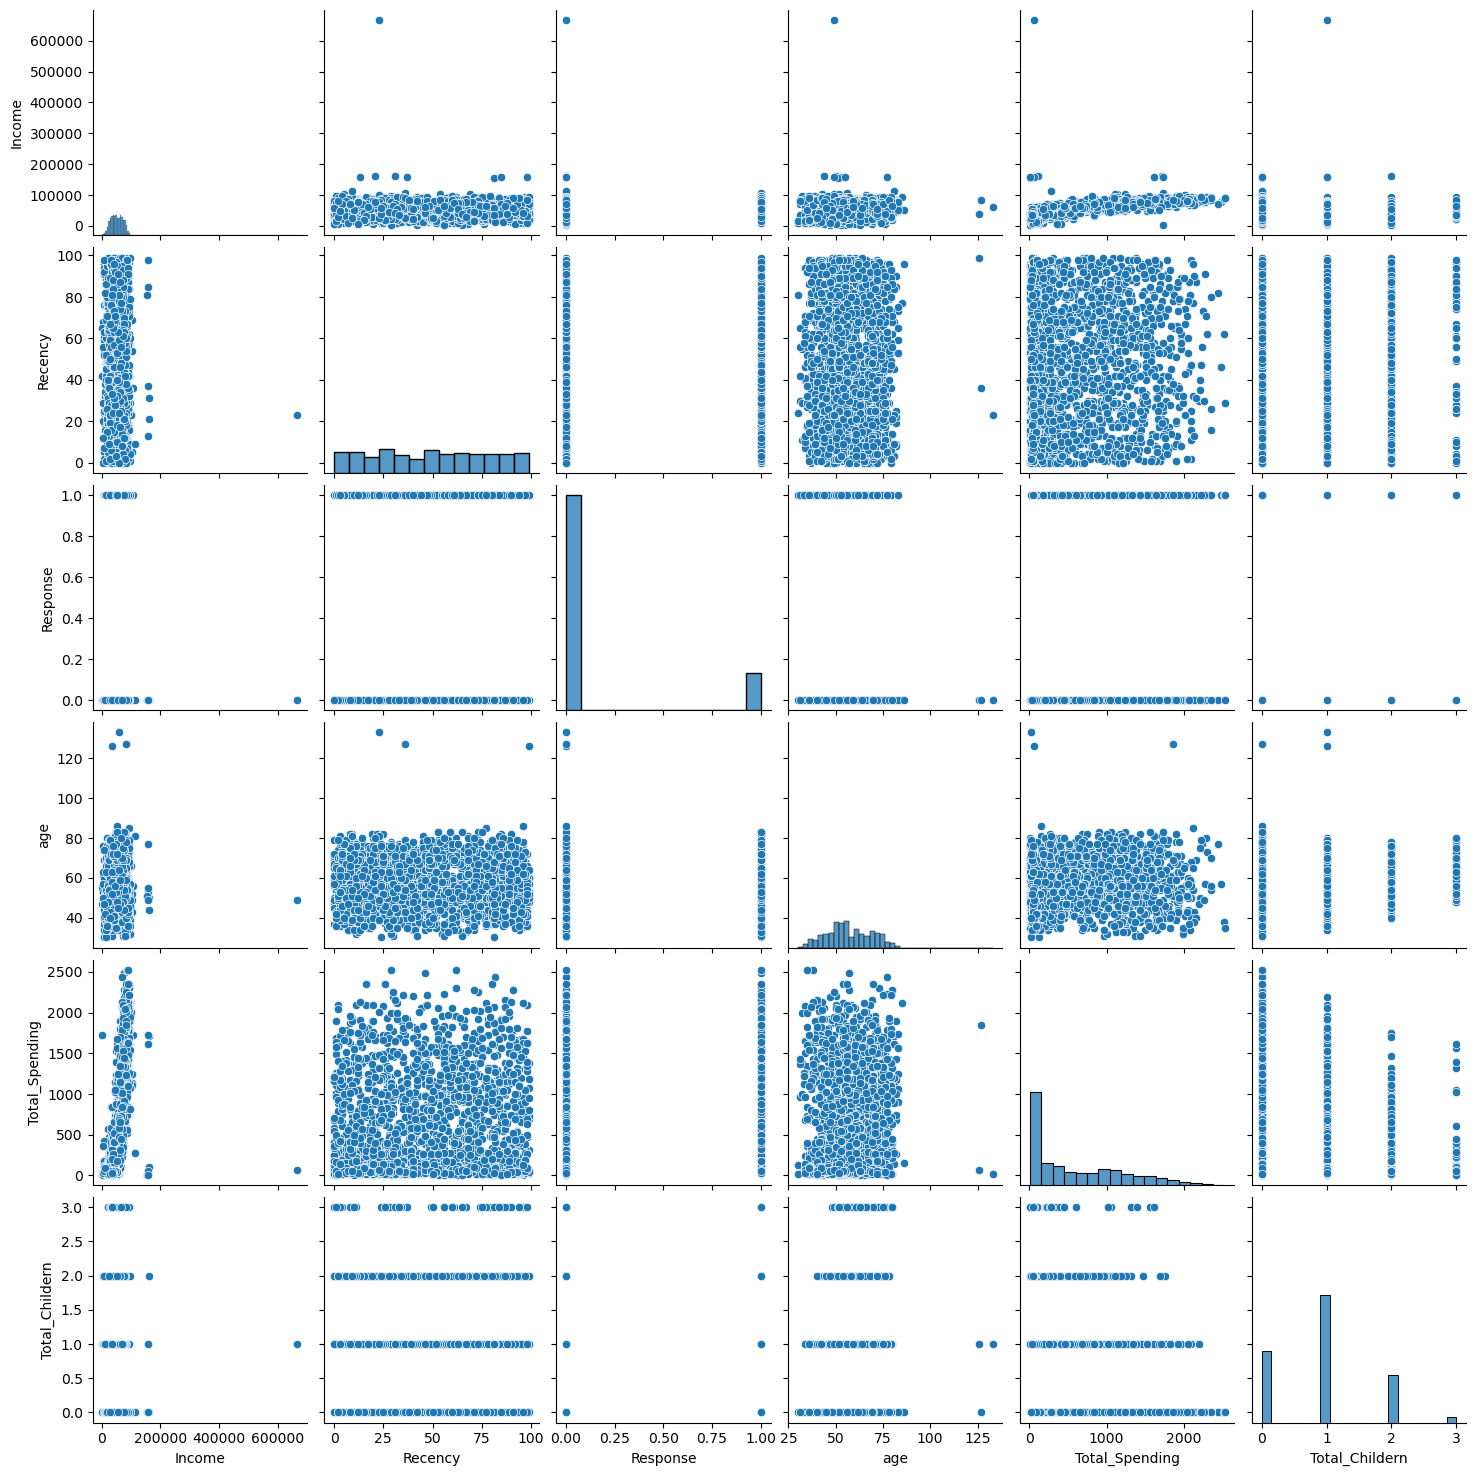

In [21]:
cols = ["Income", "Recency", "Response", "age", "Total_Spending", "Total_Childern"]

# relative plots of some features - pair plot
sns.pairplot(df_cleaned[cols])

In [22]:
# Remove Outliers
print("Data size with outliers",len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["age"] < 90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000)]

print("Data size without outliers",len(df_cleaned))

Data size with outliers 2240
Data size without outliers 2236


## Co-relation Heatmap

In [23]:
corr_matrix = df_cleaned.corr(numeric_only=True)

- **Correlation Heatmap**

A **correlation heatmap** was created to understand the relationships between different features in the dataset.

The **correlation matrix** was calculated using only the **numerical values**, because correlation works only with numeric features.

This heatmap helps to identify **strongly related features** and understand the **structure of the dataset** before applying **clustering**.

<Axes: >

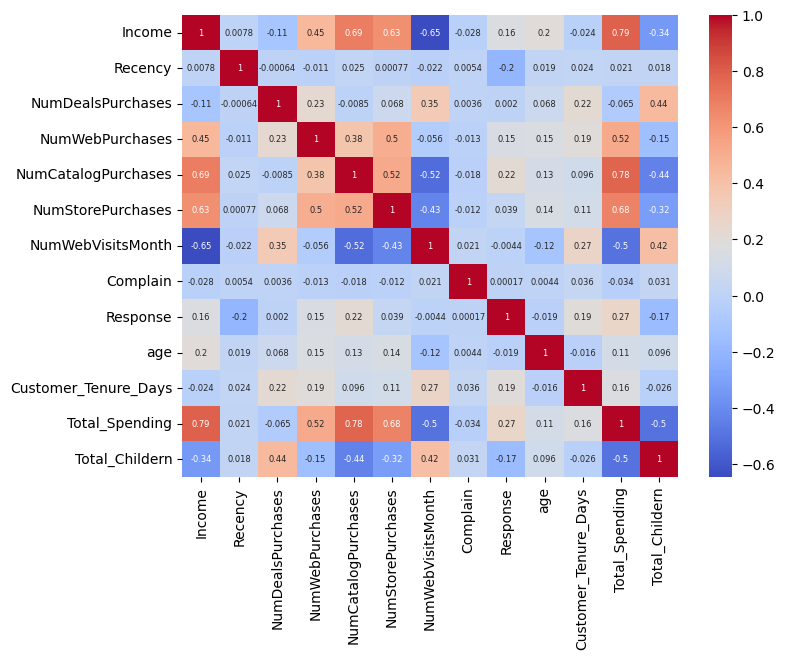

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    annot_kws = {"size" : 6},
    cmap="coolwarm"
)

- **Observations from the Correlation Heatmap**

Notice that in this **correlation heatmap**:

- **0.79 (High Correlation)** → **Income** has a strong positive correlation with **Total_Spending**

- **0.69 (High Correlation)** → **Income** has a strong positive correlation with **NumCatalogPurchases**

- **0.63 (High Correlation)** → **Income** has a strong positive correlation with **NumStorePurchases**

- **-0.65 (Negative Correlation)** → **Income** has a strong negative correlation with **NumWebVisitsMonth**

- **0.78 (High Correlation)** → **Total_Spending** has a strong positive correlation with **NumCatalogPurchases**

  etc.

In [25]:
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Childern,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Post_Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
ohe = OneHotEncoder()

cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cols])

In [28]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cols), index=df_cleaned.index)

In [29]:
df_encoded = pd.concat([df_cleaned.drop(columns=cols), enc_df], axis=1)

- **One-Hot Encoding**  → **One-Hot Encoding is preferred for clustering**

Categorical features cannot be used directly in clustering algorithms, so **One-Hot Encoding** was applied to convert categorical variables into numerical form.

The following categorical features were encoded:

- **Education**
- **Living_With**

Each category was transformed into separate binary columns, making the dataset suitable for clustering analysis.

In [30]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Childern,Education_Graduate,Education_Post_Graduate,Education_Under_Graduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
X = df_encoded

In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

- **Feature Scaling**

Feature scaling was applied because the dataset contains features with different value ranges. For example, **Income** has much larger values compared to features such as **Total_Children** and **Response**.

Scaling is very very important before applying any clustering algorithm.

In [34]:
# X_scaled

# Visualize

In [35]:
from sklearn.decomposition import PCA

In [36]:
#2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 1.0, '2D Projection')

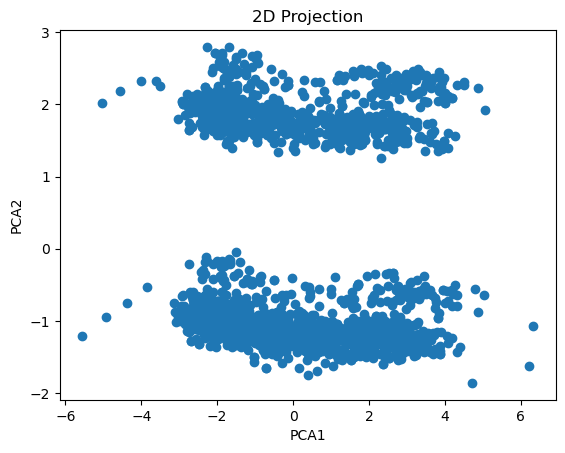

In [37]:
plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("2D Projection")

In [38]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [39]:
#3D
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [40]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

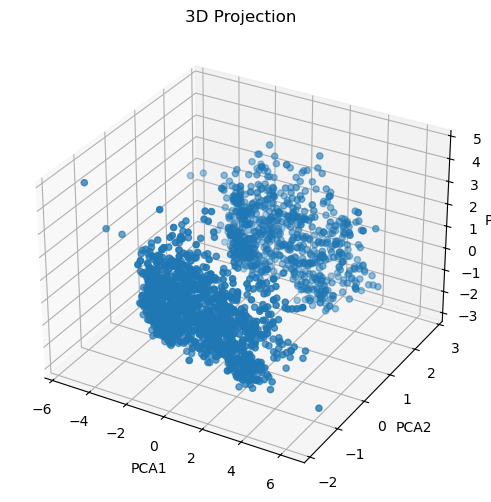

In [41]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

Principal Component Analysis (**PCA**) was applied to reduce the dimensionality of the dataset and visualize the data in lower dimensions.

First, the data was projected into **2D space** using two principal components (**PCA1** and **PCA2**) to observe the overall distribution of the data.

Then, a **3D projection** (**PCA1, PCA2, PCA3**) was created to better visualize the structure of the dataset.

However, visually identifying clusters from these scatter plots is difficult. Therefore, clustering algorithms will be applied to automatically identify patterns and group similar customers.

For the **SmartCart E-commerce dataset**, the following clustering algorithms will be used:

- **K-Means Clustering**
- **Hierarchical Clustering**

The **DBSCAN** algorithm will not be used because it is more suitable for **outlier detection** rather than typical e-commerce customer segmentation.

## Analyze K Value

1. Elbow Methid

In [42]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [43]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)   
    

In [44]:
knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
k_value = knee.elbow

print(f"Best k value = {k_value}")

Best k value = 4


Text(0, 0.5, 'WCSS')

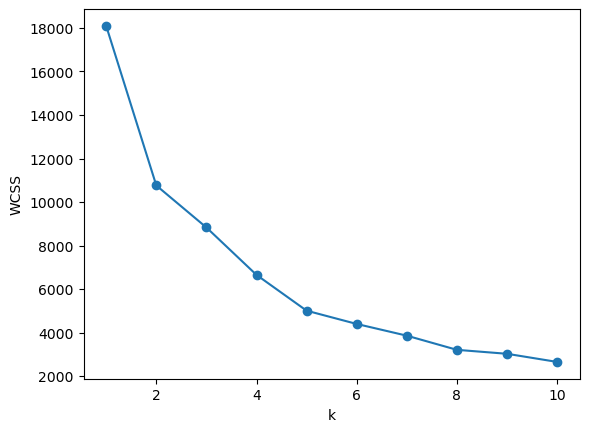

In [45]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")

2. silhouette score

In [46]:
from sklearn.metrics import silhouette_score

In [47]:
scores =[]

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

Text(0, 0.5, 'silhouette Score')

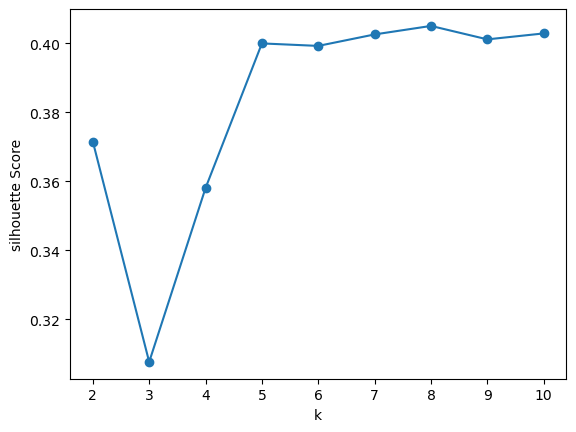

In [48]:
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("k")
plt.ylabel("silhouette Score")

Usually, we try to choose the **k** value that gives the highest **Silhouette Score**.  
In this case, the highest score is at **k = 8**, but we do not always select the exact highest value.

In the Elbow Method, the optimal value of k is 4.

Here, **k = 4** gives a good Silhouette Score and better cluster understanding. So, we select **k = 4** as the optimal number of clusters.

Generally,  **Silhouette Score** `increases`, the **WCSS (Within-Cluster Sum of Squares)** `decreases`.  
So, we try to find where these two lines `intersect`, and the `nearest k` value at that point is chosen as the optimal `k` value.

Text(0, 0.5, 'silhouette Score')

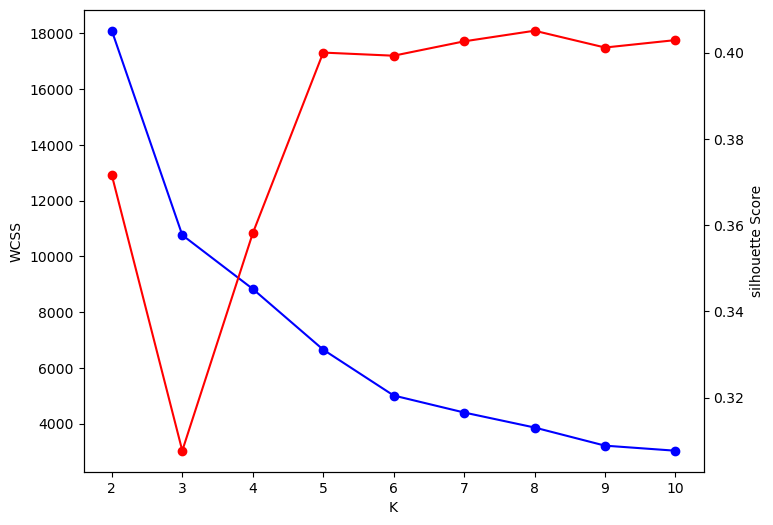

In [49]:
# Combined plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color="blue")  # wcss[:len(k_range) = Take elements from index 0 up to index 8
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")


ax2 = ax1.twinx()  # twinx() means in both graph x axis is same
ax2.plot(k_range, scores[:len(k_range)], marker='o', color="red")
ax2.set_ylabel("silhouette Score")

- By analyzing both graphs, the curves intersect around **k = 4**. Therefore, the optimal number of clusters is **k = 4**.

## Clustering 

In [50]:
# K-means

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

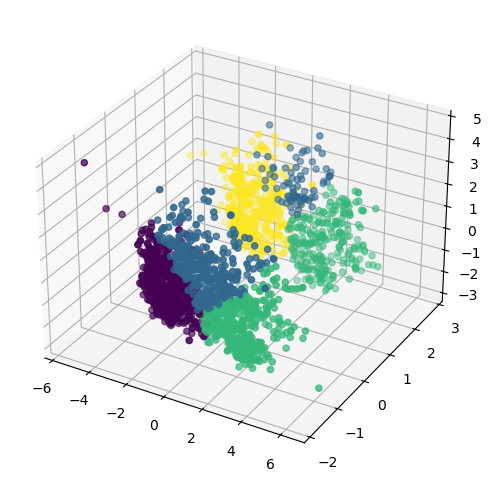

In [51]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=kmeans_labels)

In [59]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
agglomerative_labels = clustering.fit_predict(X_pca)

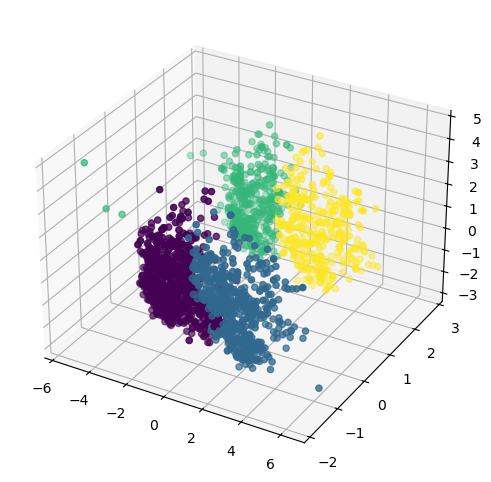

In [60]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=agglomerative_labels)

From the results, I can see that the Agglomerative Clustering algorithm performs better than the K-Means Clustering algorithm.

Therefore, I will proceed with the Agglomerative Clustering algorithm for the next steps.

## Characterization of Clusters

In [61]:
X["cluster"] = agglomerative_labels

In [62]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Childern,Education_Graduate,Education_Post_Graduate,Education_Under_Graduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


- Next, create some plots to identify what type of information is available in each cluster.

<Axes: xlabel='cluster', ylabel='count'>

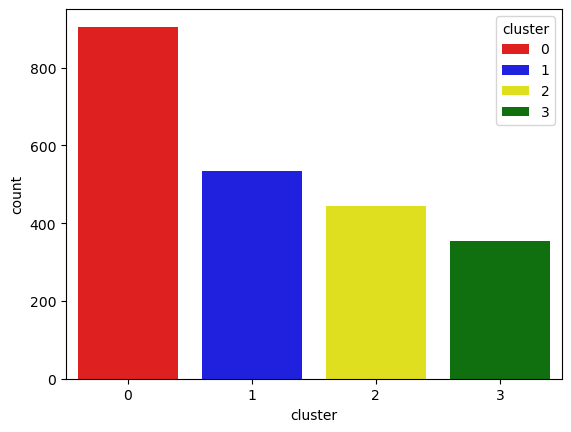

In [63]:
color_palette = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=color_palette, hue=X["cluster"])

- In the correlation heatmap, I can see that the relationship between Income and Spending is strong.  
  So, I will analyze the Income and Spending patterns in more detail.

<Axes: xlabel='Total_Spending', ylabel='Income'>

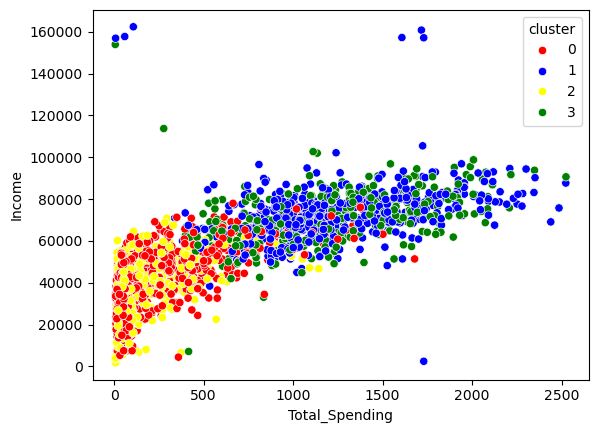

In [64]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=color_palette)

So, by observing some common characteristics based on Spending and Income:

- Cluster 0 (Red cluster) → Income is Low/Moderate & Spending is Low/Moderate.
- Cluster 1 (Blue cluster) → Compared to the Red cluster, Income is High & Spending is High.
- Cluster 2 (Yellow cluster) → Income is Low & Spending is Low.
- Cluster 3 (Green cluster) → Income is Moderate/High & Spending is High.

So, Cluster 1 and Cluster 3 have high Spending and generally high Income.  
And Cluster 0 and Cluster 2 have low Spending and low Income.

In [65]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        age  Customer_Tenure_Days  Total_Spending  \
cluster         

### Cluster Summary

- Now, it is clearly visible that in **Cluster 1 and Cluster 3**, **Income** is high and **Total_Spending** is also high.  
  In **Cluster 0 and Cluster 2**, **Income** is low and **Total_Spending** is low.

- In **Cluster 1 and Cluster 3**, Spending is high. So, these are `premium` customers.

- In **Cluster 0 and Cluster 2**, Spending is low. So, these are `price-sensitive` customers.

- If we see **Total_Children**, it is clearly visible that **Cluster 0 and Cluster 2** have more children, so Spending is low.  
  **Cluster 1 and Cluster 3** have fewer children, so Spending is high.

- If we see **Age**, **Cluster 1 and Cluster 3** have slightly higher age. Naturally, with higher age, income is also higher.

- If we see **Response**, **Cluster 3** has the highest response, **Cluster 1 and Cluster 2** have average response, and **Cluster 0** has low response.

- If we see **Living_With_Alone** and **Living_With_Partner**, **Cluster 0 and Cluster 1** are mostly living with partners, whereas **Cluster 2 and Cluster 3** are mostly living alone.

- If we see **NumWebVisitsMonth**, **Cluster 0 and Cluster 2** are more active on websites, whereas **Cluster 1 and Cluster 3** are less active (which means high spenders do not visit the website too frequently).

- If we see **NumStorePurchases**, **NumCatalogPurchases**, and **NumWebPurchases**, **Cluster 1 and Cluster 3** are high, whereas **Cluster 0 and Cluster 2** are low.

---

### Marketing Strategy for SmartCart (E-commerce Site)

- **Cluster 0** (Children high, living with partners) → **Family Shoppers** → Offer **Discount Coupons**

- **Cluster 1** (Premium customers, living with partner, purchases high) → **Loyalty Programs**

- **Cluster 2** (More children, living alone, web visits high but not buying much) → **Digital Browsers** → Provide **Heavy Discounts**

- **Cluster 3** (`Golden cluster` because High Spending & High Response) → **High Value Customers** → Offer **Premium Services**